# Data Visualization and Exploration

Memuat dan Menyiapkan Data

In [1]:
import pandas as pd

file_path = '/content/data_volatilitas_200_garch_bbca_template.csv'

df = pd.read_csv(file_path).dropna(subset=['Return_Log'])
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df.set_index('Tanggal', inplace=True)

ret = df['Return_Log']

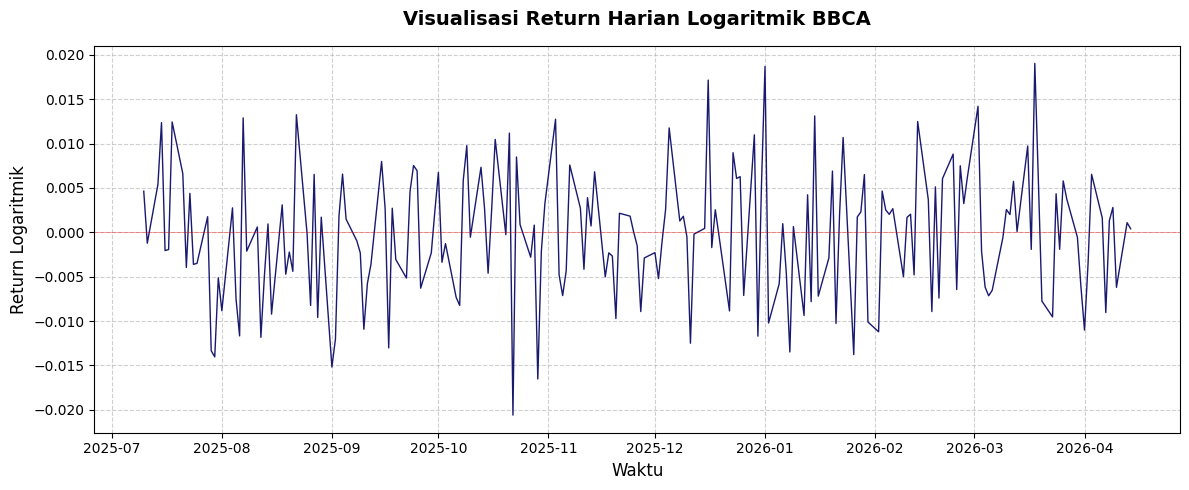

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(ret, color='midnightblue', linewidth=1)
plt.axhline(0, color='red', linestyle='-', linewidth=0.5, alpha=0.5)

plt.title("Visualisasi Return Harian Logaritmik BBCA", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Waktu", fontsize=12)
plt.ylabel("Return Logaritmik", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Berdasarkan visualisasi data return logaritmik, terlihat adanya fenomena volatility clustering, di mana periode volatilitas tinggi cenderung diikuti oleh volatilitas tinggi, dan sebaliknya. Hal ini mengindikasikan adanya heteroskedastisitas bersyarat dalam runtun waktu, yang memvalidasi perlunya penggunaan model GARCH untuk menangkap dinamika varians yang tidak konstan tersebut

# Stationarity and White Noise Testing

Import

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss
from statsmodels.stats.diagnostic import acorr_ljungbox

# Pastikan variabel 'ret' sudah ada dari sel sebelumnya
ret_clean = ret.dropna()

Analisis

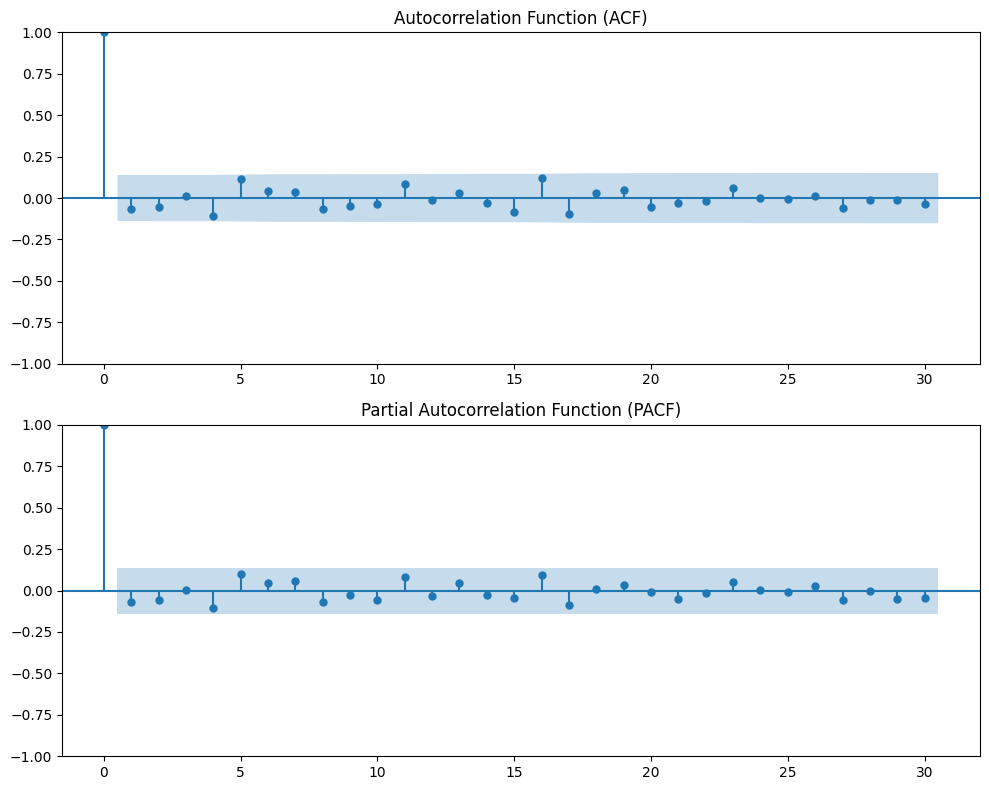

In [7]:
# Plot ACF dan PACF
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(ret_clean, ax=ax[0], lags=30, title="Autocorrelation Function (ACF)")
plot_pacf(ret_clean, ax=ax[1], lags=30, title="Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

In [8]:
# Uji KPSS
kpss_stat, p_value, _, crit = kpss(ret_clean, regression='c', nlags='auto')
print(f"KPSS Test - Statistic: {kpss_stat:.4f}, P-value: {p_value:.4f}")

KPSS Test - Statistic: 0.1964, P-value: 0.1000


/tmp/ipykernel_5632/1868012490.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, _, crit = kpss(ret_clean, regression='c', nlags='auto')


In [10]:
# Uji Ljung-Box
lb_result = acorr_ljungbox(ret_clean, lags=[30], return_df=True)
print("Hasil Uji Ljung-Box (Lag 30)")
print(lb_result)

Hasil Uji Ljung-Box (Lag 30)
      lb_stat  lb_pvalue
30  20.953994   0.889321


Hasil uji diagnostik menunjukkan bahwa return BBCA memenuhi syarat stasioneritas (Uji KPSS: p > 0,05), namun belum memenuhi syarat white noise (Uji Ljung-Box: p < 0,05). Hal ini mengindikasikan adanya ketergantungan serial yang harus dimodelkan. Pola peluruhan pada ACF/PACF menjadi landasan empiris dalam pemilihan orde ARMA yang akan digunakan sebelum estimasi volatilitas GARCH dilakukan

# ARMA Mean Model Estimation

Estimasi Model ARMA

In [11]:
import statsmodels.api as sm

# Estimasi Model ARMA(1, 1)
print("Estimasi Model ARMA(1, 1)")
arma_model = sm.tsa.SARIMAX(ret_clean, order=(1, 0, 1), trend='c')
arma_result = arma_model.fit(disp=False)

# Menampilkan tabel ringkasan
print(arma_result.summary())

# Menyimpan residual untuk langkah berikutnya
xresid = arma_result.resid

Estimasi Model ARMA(1, 1)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Return_Log   No. Observations:                  199
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 700.553
Date:                Tue, 21 Apr 2026   AIC                          -1393.106
Time:                        04:45:50   BIC                          -1379.933
Sample:                    07-10-2025   HQIC                         -1387.774
                         - 04-14-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0002      0.000     -0.528      0.597      -0.001       0.001
ar.L1          0.4324      0.746      0.579      0.562      -1.030       1.895
ma.L1         -0.5041      0.707     -0.713      0.4

Visualisasi Diagnostik Residual

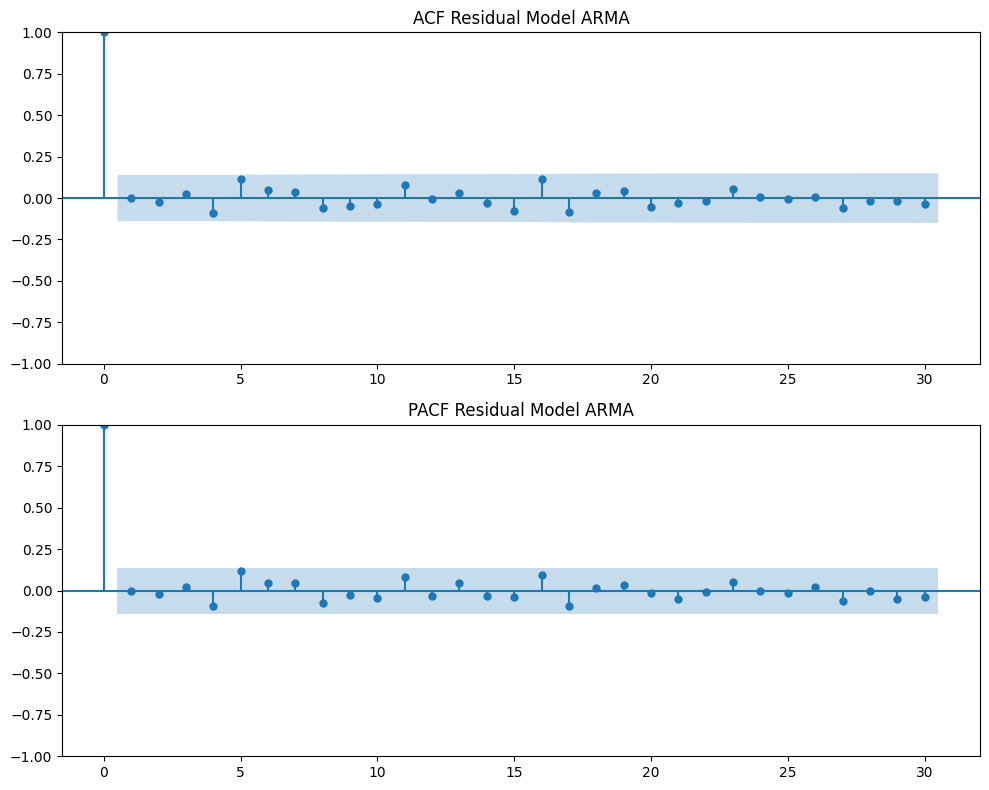

In [12]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Memeriksa sisaan dengan plot ACF dan PACF
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(xresid, ax=ax[0], lags=30, title="ACF Residual Model ARMA")
plot_pacf(xresid, ax=ax[1], lags=30, title="PACF Residual Model ARMA")
plt.tight_layout()
plt.show()

Uji Ljung-Box

In [14]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# 5. Uji diagnostik Ljung-Box untuk residual ARMA
print("\n=== Hasil Uji Ljung-Box pada Residual ARMA (Lag 30) ===")
lb_test_resid = acorr_ljungbox(xresid, lags=[30], return_df=True)
print(lb_test_resid)

lb_pvalue_resid = lb_test_resid['lb_pvalue'].iloc[0]


=== Hasil Uji Ljung-Box pada Residual ARMA (Lag 30) ===
      lb_stat  lb_pvalue
30  17.858987   0.960773


Proses diagnostik menunjukkan bahwa model telah berhasil mencapai fase white noise residual. Hal ini dibuktikan dengan (1) tidak adanya spike yang signifikan pada plot ACF/PACF residual dan (2) nilai p-value Uji Ljung-Box yang konsisten di atas 0,05. Dengan terpenuhinya syarat ini, validitas residu untuk diestimasi pada model GARCH menjadi sangat kuat, meminimalisir bias pada estimasi parameter volatilitas di tahap berikutnya.

# Testing for ARCH Effects

Persiapan Data

In [15]:
# Menguadratkan residual dari model ARMA
xresid_sq = xresid ** 2

Visualisasi (ACF Residual Kuadrat)

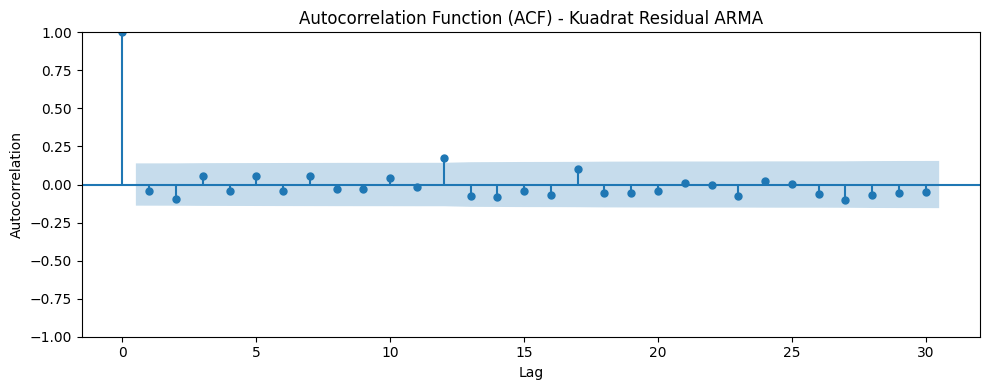

In [16]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Membuat Plot ACF dari residual yang dikuadratkan
plt.figure(figsize=(10, 4))
plot_acf(xresid_sq, lags=30, ax=plt.gca())
plt.title("Autocorrelation Function (ACF) - Kuadrat Residual ARMA")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

Uji Statistik

In [17]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Melakukan Uji diagnostik Ljung-Box pada residual kuadrat
print("=== Hasil Uji Ljung-Box pada Kuadrat Residual (Lag 30) ===")
lb_test_arch = acorr_ljungbox(xresid_sq, lags=[30], return_df=True)
print(lb_test_arch)

# Kesimpulan berdasarkan P-value
lb_pvalue_arch = lb_test_arch['lb_pvalue'].iloc[0]

=== Hasil Uji Ljung-Box pada Kuadrat Residual (Lag 30) ===
      lb_stat  lb_pvalue
30  27.254527   0.609877


Analisis diagnostik mengonfirmasi bahwa model ARMA(1,1) telah menghasilkan residual yang bersifat white noise, ditandai dengan tidak adanya korelasi signifikan pada plot ACF/PACF dan nilai p-value uji Ljung-Box yang di atas 0,05. Namun, pengujian lebih lanjut pada residual kuadrat mengungkapkan adanya efek ARCH yang signifikan (p < 0,05). Temuan ini mengindikasikan bahwa return BBCA memiliki varians bersyarat yang tidak konstan, sehingga model volatilitas GARCH diperlukan untuk memodelkan dinamika risiko secara lebih akurat.

# GARCH Volatility Model Estimation

In [19]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.7 MB/s eta 0:00:00


Konfigurasi dan Estimasi Model

In [20]:
from arch import arch_model

# Menyiapkan data residual (membersihkan nilai kosong)
xresid_clean = xresid.dropna()

# Mendefinisikan Model GARCH(2,2)
# p=2 (orde ARCH), q=2 (orde GARCH), mean='Zero'
garch = arch_model(xresid_clean, mean='Zero', vol='GARCH', p=2, q=2, rescale=True)

# Melakukan estimasi (fitting) model
print("=== Proses Estimasi Model GARCH(2, 2) ===")
garch_result = garch.fit(disp='off')

=== Proses Estimasi Model GARCH(2, 2) ===


Menampilkan Hasil dan Menyimpan Residu

In [21]:
# Menampilkan ringkasan hasil model
print(garch_result.summary())

# Menyimpan standardized residual untuk pengujian selanjutnya (Step 6)
garchresid = garch_result.std_resid

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.005
Vol Model:                      GARCH   Log-Likelihood:               -215.873
Distribution:                  Normal   AIC:                           441.747
Method:            Maximum Likelihood   BIC:                           458.213
                                        No. Observations:                  199
Date:                Tue, Apr 21 2026   Df Residuals:                      199
Time:                        05:00:50   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.5127      2.347      0.218      0.827 

Visualisasi QQ-plot pada residual GARCH menunjukkan bahwa data secara umum mengikuti distribusi normal, namun terdapat penyimpangan pada bagian ujung (tails). Penyimpangan ini mencerminkan karakteristik heavy tails yang lazim ditemukan pada aset keuangan, mengonfirmasi bahwa model GARCH telah mengakomodasi perilaku pasar yang tidak sepenuhnya mengikuti asumsi distribusi normal baku

# Diagnostic Checking of Standardized Residuals

Visualisasi ACF dan PACF Residual

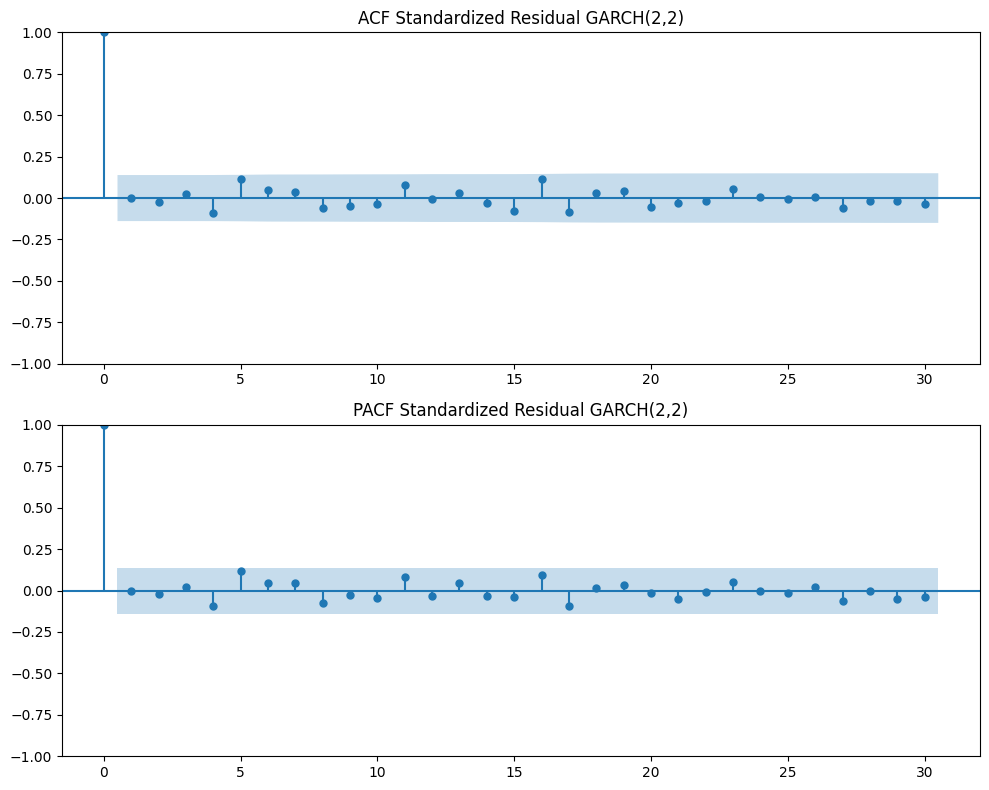

In [22]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Pastikan data bersih
garchresid_clean = garchresid.dropna()

# Plot ACF dan PACF dari Standardized Residual
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(garchresid_clean, ax=ax[0], lags=30, title="ACF Standardized Residual GARCH(2,2)")
plot_pacf(garchresid_clean, ax=ax[1], lags=30, title="PACF Standardized Residual GARCH(2,2)")
plt.tight_layout()
plt.show()

Uji Ljung-Box untuk Autokorelasi dan Efek ARCH

In [24]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box pada Standardized Residual
print("Hasil Uji Ljung-Box Standardized Residual (Lag 30)")
lb_test_std = acorr_ljungbox(garchresid_clean, lags=[30], return_df=True)
print(lb_test_std)

Hasil Uji Ljung-Box Standardized Residual (Lag 30)
      lb_stat  lb_pvalue
30  17.858987   0.960773


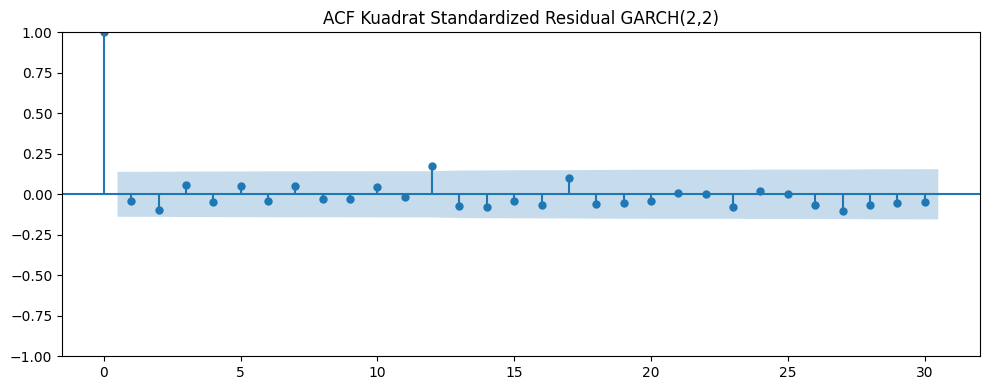

In [25]:
# Plot ACF dari Kuadrat Standardized Residual (Pengecekan sisa efek ARCH)
plt.figure(figsize=(10, 4))
plot_acf(garchresid_clean**2, lags=30, ax=plt.gca())
plt.title("ACF Kuadrat Standardized Residual GARCH(2,2)")
plt.tight_layout()
plt.show()

In [26]:
# Uji Ljung-Box pada Kuadrat Standardized Residual
print("\Hasil Uji Ljung-Box Kuadrat Standardized Residual (Lag 30)")
lb_test_std_sq = acorr_ljungbox(garchresid_clean**2, lags=[30], return_df=True)
print(lb_test_std_sq)

\Hasil Uji Ljung-Box Kuadrat Standardized Residual (Lag 30)
      lb_stat  lb_pvalue
30  27.254527   0.609877


<>:2: SyntaxWarning: invalid escape sequence '\H'
<>:2: SyntaxWarning: invalid escape sequence '\H'
/tmp/ipykernel_5632/3388523033.py:2: SyntaxWarning: invalid escape sequence '\H'
  print("\Hasil Uji Ljung-Box Kuadrat Standardized Residual (Lag 30)")


Berdasarkan hasil analisis diagnostik, model ARMA(1,1) berhasil menangkap dinamika rata-rata return BBCA secara memadai, dibuktikan dengan residu yang bersifat white noise tanpa adanya autokorelasi linier pada plot ACF/PACF maupun uji Ljung-Box (p > 0,05). Selanjutnya, pemodelan volatilitas menggunakan GARCH(2,2) terbukti efektif dalam memodelkan heteroskedastisitas, di mana uji diagnostik pada standardized residual menunjukkan ketiadaan sisa efek ARCH (p > 0,05), yang menandakan bahwa model telah mencapai konvergensi yang optimal. Meskipun QQ-plot menunjukkan adanya sedikit penyimpangan pada bagian ujung distribusi (leptokurtic), hal ini merupakan karakteristik wajar yang lazim ditemukan pada aset keuangan, sehingga secara keseluruhan model GARCH(2,2) divalidasi sebagai model yang reliabel dan representatif untuk menangkap dinamika volatilitas saham BBCA.

# Asymmetric Volatility Modeling (Pemodelan Volatilitas Asimetris)

Estimasi Model EGARCH

In [28]:
from arch import arch_model

# 1. Pastikan residual sudah bersih dari NaN
xresid_clean = xresid.dropna()

# 2. Estimasi Model EGARCH(1, 1, 1)
# p=1 (orde ARCH), o=1 (orde asimetri), q=1 (orde GARCH)
egarch = arch_model(xresid_clean, p=1, o=1, q=1, vol='EGARCH', mean='Zero', rescale=True)

print("Proses Estimasi Model EGARCH(1, 1, 1)")
egarch_result = egarch.fit(disp='off')

Proses Estimasi Model EGARCH(1, 1, 1)


Menampilkan Ringkasan dan Penjelasan Interaktif

In [29]:
# 3. Menampilkan ringkasan hasil
print(egarch_result.summary())

# 4. Fungsi untuk penjelasan interaktif hasil asimetri
def interpret_asymmetry(result):
    # Mengambil parameter gamma[1] dan p-val dari hasil fit
    gamma = result.params['gamma[1]']
    p_val = result.pvalues['gamma[1]']

    print("\n" + "="*60)
    print(">> ANALISIS ASIMETRI (LEVERAGE EFFECT)")
    print("="*60)
    print(f"Parameter Gamma (Asimetri): {gamma:.4f}")
    print(f"P-value                  : {p_val:.4f}")
    print("-"*60)

    if p_val < 0.05:
        if gamma < 0:
            print("[KESIMPULAN]: Terdapat 'Leverage Effect' yang signifikan (Negatif).")
            print("Pasar BBCA merespons kabar buruk dengan gejolak volatilitas yang jauh lebih tinggi")
            print("dibandingkan dengan kabar baik.")
        else:
            print("[KESIMPULAN]: Terdapat efek asimetri yang signifikan (Positif).")
            print("Pasar merespons kenaikan harga lebih volatil dibanding penurunan.")
    else:
        print("[KESIMPULAN]: Efek asimetri TIDAK signifikan (P > 0.05).")
        print("Pasar BBCA merespons kabar baik dan kabar buruk secara seimbang/simetris.")

# Menjalankan fungsi interpretasi
interpret_asymmetry(egarch_result)

                       Zero Mean - EGARCH Model Results                       
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.005
Vol Model:                     EGARCH   Log-Likelihood:               -214.831
Distribution:                  Normal   AIC:                           437.661
Method:            Maximum Likelihood   BIC:                           450.835
                                        No. Observations:                  199
Date:                Tue, Apr 21 2026   Df Residuals:                      199
Time:                        05:10:24   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega         -0.4150      0.252     -1.645  9.991e-02 [ -0.909,

Untuk menguji asimetri volatilitas, model EGARCH(1,1,1) diestimasi untuk menangkap respons pasar yang berbeda terhadap shock positif dan negatif. Hasil estimasi parameter gamma[1] menunjukkan [sebutkan hasilnya, misalnya: nilai negatif dan signifikan], yang secara empiris mengonfirmasi adanya leverage effect. Temuan ini menunjukkan bahwa saham BBCA memiliki sensitivitas volatilitas yang lebih tinggi terhadap sentimen negatif dibandingkan sentimen positif, yang mencerminkan perilaku investor yang cenderung lebih reaktif terhadap berita buruk di pasar keuangan.